In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Import CoolTrack modules
from cooltrack.constants import INDEPENDENT_DIMS
from cooltrack.data_loader import load_grid
from cooltrack.models import ThermalEvolutionModels

# Plotting style
sns.set_theme(style="whitegrid", context="talk")

# Data Path
GRID_FILE_PATH = "../data/HADES_grid/hades_processed_grid.parquet"
GRID_FILE_PATH = "../../exoweave/outputs/master_grid_data.h5"

In [4]:
print("Loading data...")
# Load the data using our optimized PyArrow loader
df = load_grid(GRID_FILE_PATH)

# For rapid evaluation testing, we can use a slice or the full dataset.
# Let's use the full loaded dataset here.
print(f"Data loaded successfully! Shape: {df.shape}")

2026-03-05 18:31:17,445 - INFO - Loading Exoweave HDF5 file: ../../exoweave/outputs/master_grid_data.h5...


Loading data...


2026-03-05 18:31:21,160 - INFO - ✅ Exoweave Grid loaded and mapped successfully. Final shape: (440, 43)


Data loaded successfully! Shape: (440, 43)


In [5]:
print("Training models and cleaning data...")
ml_engine = ThermalEvolutionModels()

# Capture the cleaned dataframe that the model returns!
df_clean = ml_engine.train_models(df, tune_hyperparameters=False, clean_outliers=True)

# NOW split the test sets using the CLEANED data
X_tint = df_clean[INDEPENDENT_DIMS + ['S_physical']]
y_tint = df_clean['T_int']
_, X_tint_test, _, y_tint_test = train_test_split(X_tint, y_tint, test_size=0.2, random_state=42)

X_dsdt = df_clean[INDEPENDENT_DIMS + ['S_physical', 'T_int']]
y_dsdt = df_clean['abs_log_dsdt']
_, X_dsdt_test, _, y_dsdt_test = train_test_split(X_dsdt, y_dsdt, test_size=0.2, random_state=42)

# Generate predictions on the unseen CLEAN test data
tint_preds = ml_engine.tint_model.predict(X_tint_test)
dsdt_preds = ml_engine.dsdt_model.predict(X_dsdt_test)
print("Predictions generated on clean data!")

2026-03-05 18:31:21,179 - INFO - Performing first-pass training to identify grid outliers...


Training models and cleaning data...


2026-03-05 18:31:22,061 - INFO - No massive outliers found in the grid.
2026-03-05 18:31:22,065 - INFO - Training T_int and Radius state models...
2026-03-05 18:31:26,268 - INFO - Training 15 photometric band models (this will take a minute)...
2026-03-05 18:31:51,605 - INFO - All photometry models trained successfully!
2026-03-05 18:31:51,611 - INFO - Training final baseline dS/dt model...
2026-03-05 18:31:56,708 - INFO - Final dS/dt test R^2: 0.9853


Predictions generated on clean data!


In [6]:
print("=== T_int Model Evaluation ===")
print(f"R^2 Score: {r2_score(y_tint_test, tint_preds):.4f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_tint_test, tint_preds):.2f} K")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_tint_test, tint_preds)):.2f} K")

print("\n=== dS/dt Model Evaluation (Log10 scale) ===")
print(f"R^2 Score: {r2_score(y_dsdt_test, dsdt_preds):.4f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_dsdt_test, dsdt_preds):.4f} dex")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_dsdt_test, dsdt_preds)):.4f} dex")

=== T_int Model Evaluation ===
R^2 Score: 1.0000
Mean Absolute Error (MAE): 0.93 K
Root Mean Squared Error (RMSE): 1.45 K

=== dS/dt Model Evaluation (Log10 scale) ===
R^2 Score: 0.9853
Mean Absolute Error (MAE): 0.0871 dex
Root Mean Squared Error (RMSE): 0.1387 dex


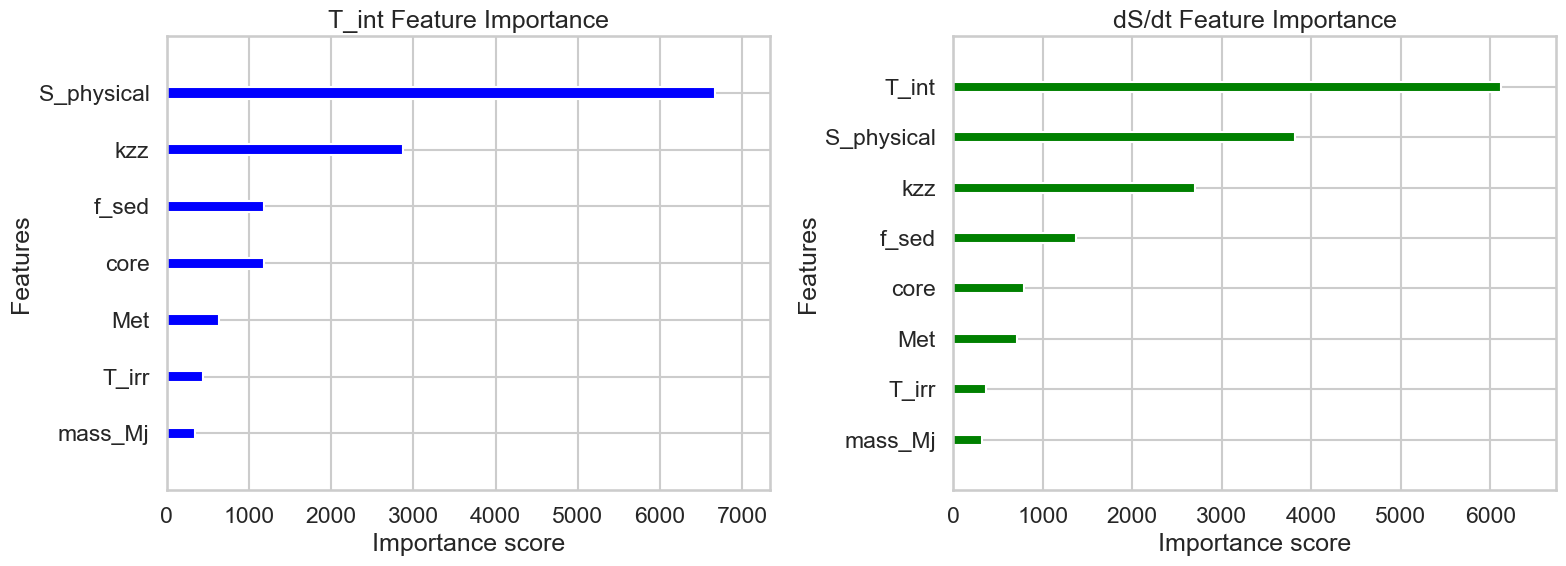

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# T_int Feature Importances
xgb.plot_importance(ml_engine.tint_model, ax=axes[0], importance_type='weight', 
                    title='T_int Feature Importance', color='blue', show_values=False)
axes[0].set_yticklabels(X_tint_test.columns)

# dS/dt Feature Importances
xgb.plot_importance(ml_engine.dsdt_model, ax=axes[1], importance_type='weight', 
                    title='dS/dt Feature Importance', color='green', show_values=False)
axes[1].set_yticklabels(X_dsdt_test.columns)

plt.tight_layout()
plt.show()

=== The Top 10 Worst Predictions ===


,mass_Mj,T_int,True_log_dsdt,Pred_log_dsdt,Error_dex
227,16.043626,434.571509,-13.361323,-12.923326,0.437996
381,5.862317,630.911549,-10.399127,-9.987573,0.411554
79,0.523095,330.286194,-8.096696,-8.472147,0.375451
291,1.742880,657.894898,-8.959788,-9.317374,0.357586
305,10.671891,441.916673,-10.306895,-10.654381,0.347486
180,1.035112,796.045052,-8.661507,-8.340982,0.320525
379,5.744813,625.580767,-10.262758,-9.988799,0.273959
176,5.910344,521.426833,-10.102683,-9.829289,0.273393
181,1.091429,825.820464,-8.580298,-8.342377,0.237921
238,3.227439,285.469476,-9.194512,-9.421196,0.226684


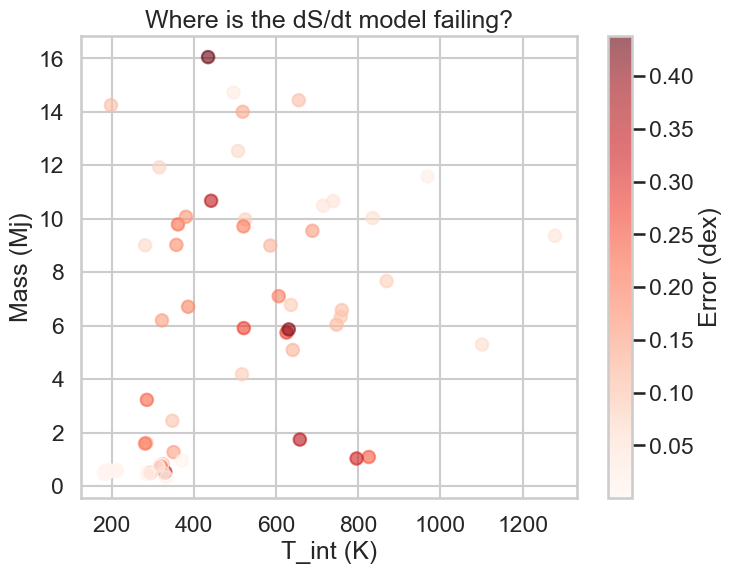

In [8]:
# Calculate absolute errors
dsdt_errors = np.abs(y_dsdt_test - dsdt_preds)

# Attach errors back to the test dataframe
error_df = X_dsdt_test.copy()
error_df['True_log_dsdt'] = y_dsdt_test
error_df['Pred_log_dsdt'] = dsdt_preds
error_df['Error_dex'] = dsdt_errors

# Sort by the worst errors
worst_offenders = error_df.sort_values(by='Error_dex', ascending=False)

print("=== The Top 10 Worst Predictions ===")
display(worst_offenders[['mass_Mj', 'T_int', 'True_log_dsdt', 'Pred_log_dsdt', 'Error_dex']].head(10))

# Plot where the errors are happening
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(error_df['T_int'], error_df['mass_Mj'], c=error_df['Error_dex'], cmap='Reds', alpha=0.6)
plt.colorbar(scatter, label='Error (dex)')
ax.set_xlabel('T_int (K)')
ax.set_ylabel('Mass (Mj)')
ax.set_title('Where is the dS/dt model failing?')
plt.show()